<a href="https://colab.research.google.com/github/viplove21r/Machine-Learning--Digit-Recognition/blob/main/MNIST_Handwritten_Digits_Recognition_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset Information

This dataset allows you to study, analyze and recognize elements in the images. That’s exactly how your camera detects your face, using image recognition! It’s a digit recognition problem. This data set has 49,000 images of 28 X 28 size, totalling 49 MB.

## Import Modules

In [ ]:
!pip install tensorflow

In [4]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from keras.preprocessing.image import img_to_array, load_img
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')

## Unzip the train data|

In [ ]:
!unzip Train_UQcUa52.zip

## Load the data

In [6]:
df = pd.read_csv('train.csv')
df.head()

,filename,label
0,0.png,4
1,1.png,9
2,2.png,1
3,3.png,7
4,4.png,3


In [7]:
!pwd

/content


In [8]:
image_path = 'Images/train/'

In [ ]:
X = np.array([
    img_to_array(
        load_img(
            image_path + df['filename'][i],
            target_size=(28, 28),
            color_mode='grayscale'
        )
    )
    for i in tqdm(range(df.shape[0]))
]).astype('float32')

In [11]:
y = df['label']

In [12]:
print(X.shape, y.shape)

(49000, 28, 28, 1) (49000,)


## Exploratory Data Analysis

4


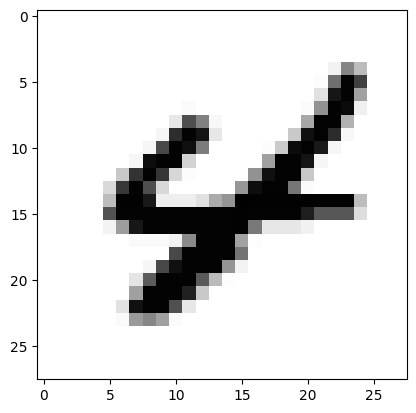

In [13]:
image_index = 0
print(y[image_index])
plt.imshow(X[image_index].reshape(28,28), cmap='Greys')

2


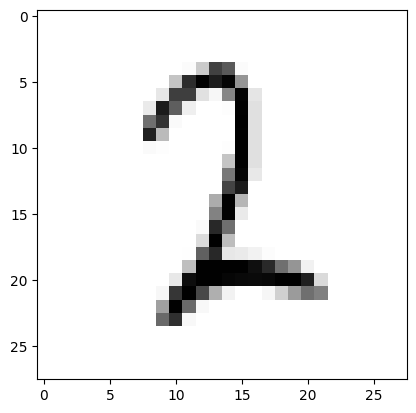

In [14]:
image_index = 10
print(y[image_index])
plt.imshow(X[image_index].reshape(28,28), cmap='Greys')

7


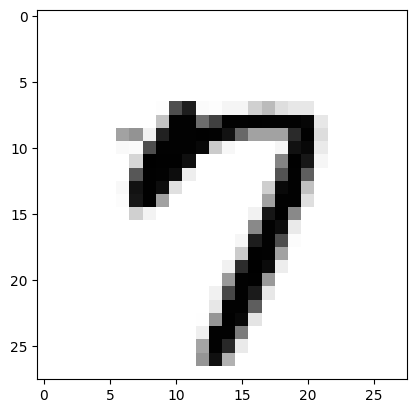

In [15]:
image_index = 100
print(y[image_index])
plt.imshow(X[image_index].reshape(28,28), cmap='Greys')

## Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=np.array(y))

## Normalization

In [17]:
x_train /= 255
x_test /= 255

## Model Creation

In [18]:
input_shape = (28,28,1)
output_class = 10

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

model = Sequential()

model.add(Conv2D(28, kernel_size=(3,3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(output_class, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# train the model
model.fit(x=x_train, y=y_train, batch_size=32, epochs=30, validation_data=(x_test, y_test))

Epoch 1/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9293 - loss: 0.2430 - val_accuracy: 0.9709 - val_loss: 0.0972
Epoch 2/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9730 - loss: 0.0875 - val_accuracy: 0.9776 - val_loss: 0.0714
Epoch 3/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9799 - loss: 0.0609 - val_accuracy: 0.9832 - val_loss: 0.0574
Epoch 4/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9851 - loss: 0.0462 - val_accuracy: 0.9829 - val_loss: 0.0588
Epoch 5/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9878 - loss: 0.0372 - val_accuracy: 0.9842 - val_loss: 0.0549
Epoch 6/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9898 - loss: 0.0304 - val_accuracy: 0.9838 - val_loss: 0.0584
Epoch 7/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9910 - loss: 0.0255 - val_accuracy: 0.9856 - val_loss: 0.0544
Epoch 8/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9927 - loss: 0.0200 -

## Testing the model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
Predicted output: 1


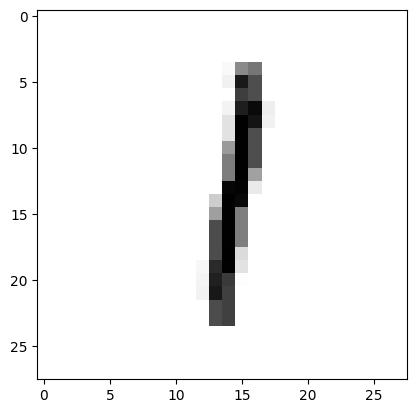

In [22]:
image_index = 10
# print("Original output:",y_test[image_index])
plt.imshow(x_test[image_index].reshape(28,28), cmap='Greys')
pred = model.predict(x_test[image_index].reshape(1,28,28,1))
print("Predicted output:", pred.argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted output: 8


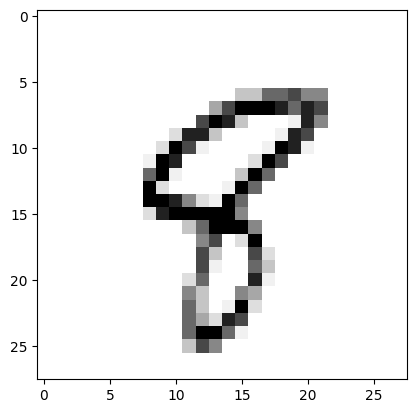

In [23]:
image_index = 100
# print("Original output:",y_test[image_index])
plt.imshow(x_test[image_index].reshape(28,28), cmap='Greys')
pred = model.predict(x_test[image_index].reshape(1,28,28,1))
print("Predicted output:", pred.argmax())